# Визначення функції надійності системи
Cтруктурна схема та λ-характеристики представлені на рисунках.
Знайти:
- функцію надійності всієї системи;
- ймовірність відмови;
- середнє напрацювання на відмову.

Отримані результати перевірити за допомогою імітаційного моделювання

![title](img.png)

λ1=λ4=0,006 , λ2=λ5=0,004 , λ3=0,01

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
class Element:
    def __init__(self, failure_rate: float):
        """
        Represents a single system element with a failure rate.

        :param failure_rate: Failure rate (lambda) of the element.
        """

        self.failure_rate = failure_rate

    def reliability(self, time: float) -> float:
        return np.exp(-self.failure_rate * time)


class System:
    def __init__(self, elements: dict[str, list[list[Element]]]):
        """
        Represents a system of elements connected in a specific structure.

        :param elements: A dictionary representing series or parallel connections.
                         Keys are connection types ("series" or "parallel") and
                         values are lists of Element objects.
        """

        self.elements = elements

    def reliability(self, time: float) -> float:
        parallel_reliability = 1 - np.prod([
            1 - np.prod([el.reliability(time) for el in group])
            for group in self.elements['parallel']
        ])

        series_reliability = np.prod([
            np.prod([el.reliability(time) for el in group])
            for group in self.elements['series']
        ])

        return parallel_reliability * series_reliability

    def plot_diagram(self, time_serials: list[float]):
        reliabilities = [self.reliability(t) for t in time_serials]
        plt.figure(figsize=(10, 6))
        plt.plot(time_serials, reliabilities, label='System Reliability')
        plt.title('System Reliability Over Time')
        plt.xlabel('Time (t)')
        plt.ylabel('Reliability R(t)')
        plt.grid()
        plt.legend()
        plt.show()

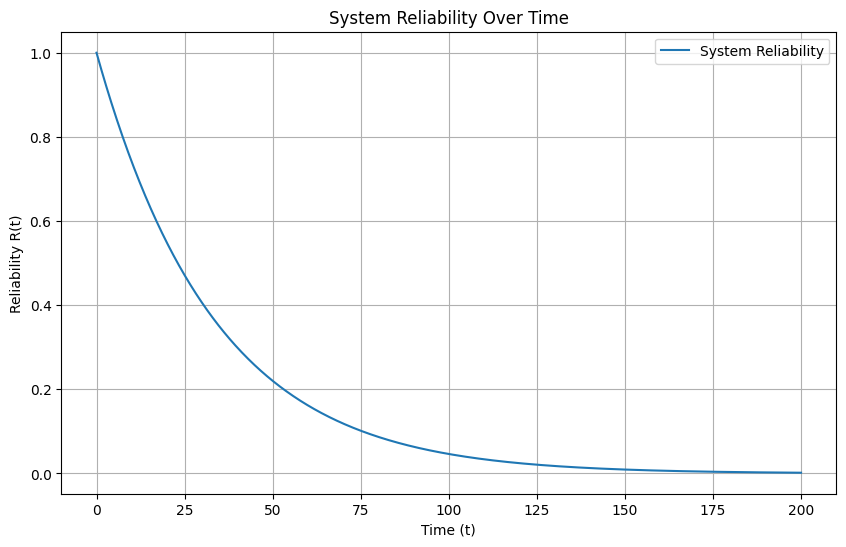

In [7]:
element_1 = Element(0.006)
element_2 = Element(0.004)
element_3 = Element(0.01)
element_4 = Element(0.006)
element_5 = Element(0.004)

system = System(
    elements={
        'parallel': [
            [element_2], [element_3], [element_5]
        ],
        'series': [
            [element_1, element_2], [element_3], [element_4, element_5]
        ]
    }
)
system.plot_diagram(time_serials=np.linspace(0, 200, 1000))